# 模块三：RFM 动态分群与 XGBoost 流失预测 (RFM & Churn Prediction)

**本模块核心目标：**
1. **算法严谨性自证：** 拒绝“拍脑袋”定 K 值，通过计算 Inertia（肘部法则）与 Silhouette Score（轮廓系数）寻找最优聚类数。
2. **动态 RFM 聚类：** 应用 K-Means 进行无监督聚类，并根据 R, F, M 的实际均值排名进行**动态打标**，告别脆弱的硬编码。
3. **机器预测落地：** 引入 `XGBoost`，将用户的 RFM 资产与履约体验（物流时长、运费）结合，训练流失预测分类器。

In [1]:
# 1. 开启自动重载
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# 引入我们重构后的高级 RFM 引擎
sys.path.append('../')
from src.rfm import RFMAnalyzer

# 2. 承接模块二：加载 ABT 宽表
print("Loading Analytical Base Table...")
df_master = pd.read_parquet("../data/processed/olist_master_abt.parquet")
print(f"ABT Loaded. Shape: {df_master.shape}")

Loading Analytical Base Table...
ABT Loaded. Shape: (110710, 22)


## 步骤一：K-Means 参数寻优 (Algorithm Rigor)
在执行聚类前，我们需要证明为什么选择 K=4。
* **Inertia (肘部法则):** 评估簇内误差平方和，越小越好，寻找下降斜率突然变缓的“肘点”。
* **Silhouette Score (轮廓系数):** 评估簇间分离度，值越接近 1 说明聚类效果越好。

Evaluating K choices (this may take a few seconds)...


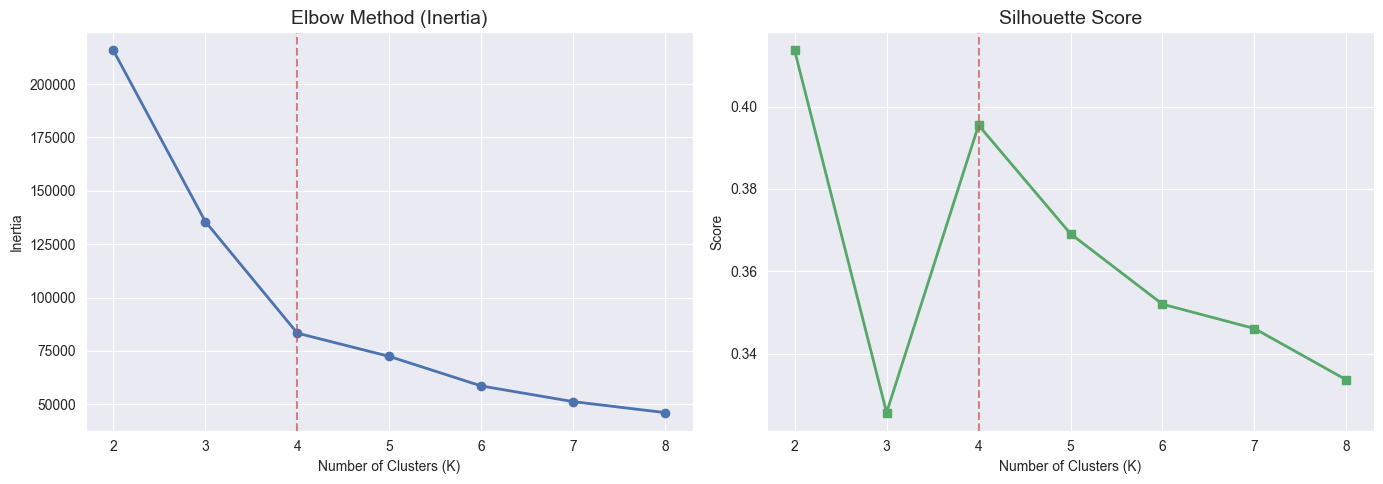

In [2]:
# 3. 实例化 RFM 分析器并进行 K 值评估
rfm_model = RFMAnalyzer(df_master)
print("Evaluating K choices (this may take a few seconds)...")
k_eval_metrics = rfm_model.evaluate_k_choices(max_k=8)

# 4. 双图展示评估结果
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# 图 1：肘部法则
axes[0].plot(k_eval_metrics['k'], k_eval_metrics['inertia'], marker='o', color='b', linewidth=2)
axes[0].set_title('Elbow Method (Inertia)', fontsize=14)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='r', linestyle='--', alpha=0.7) # 标注我们最终选定的 K=4

# 图 2：轮廓系数
axes[1].plot(k_eval_metrics['k'], k_eval_metrics['silhouette'], marker='s', color='g', linewidth=2)
axes[1].set_title('Silhouette Score', fontsize=14)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Score')
axes[1].axvline(x=4, color='r', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 步骤二：执行分群与动态打标
运用选定的模型生成用户群体，展示每个群体的规模和价值分布。

In [3]:
# 5. 生成最终的 RFM 分群数据
df_rfm = rfm_model.generate_rfm_segments()

# 6. 验证动态打标结果，输出每个群体的业务画像
segment_profile = df_rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum', 'count']
}).round(1)

segment_profile.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Total_Revenue', 'User_Count']
segment_profile['User_Share'] = (segment_profile['User_Count'] / len(df_rfm) * 100).round(1).astype(str) + '%'

print("✅ RFM 业务群体画像：")
display(segment_profile.sort_values('Total_Revenue', ascending=False))

✅ RFM 业务群体画像：


,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,User_Count,User_Share
Segment,,,,,,
Sleeping Big-Spenders,282.1,1.0,298.6,9577999.9,32075,34.2%
Low-Value Churned,297.3,1.0,68.1,2856952.9,41932,44.7%
Promising New,50.2,1.0,134.4,2281489.1,16973,18.1%
VIP Loyalists,228.0,2.1,310.5,884405.9,2848,3.0%


## 步骤三：体验特征引入与 XGBoost 流失预测
**业务假设：** 用户流失不仅与交易频次相关，还与平台的履约体验（如：物流是否太慢？运费是否太贵？）高度相关。
**动作：** 训练 XGBoost 模型预测流失倾向，并通过提取特征重要性 (Feature Importance) 来验证假设。

🚀 XGBoost Model Trained Successfully! 
ROC-AUC Score: 0.8826
(AUC 分数说明模型具备良好的区分流失与非流失用户的能力)


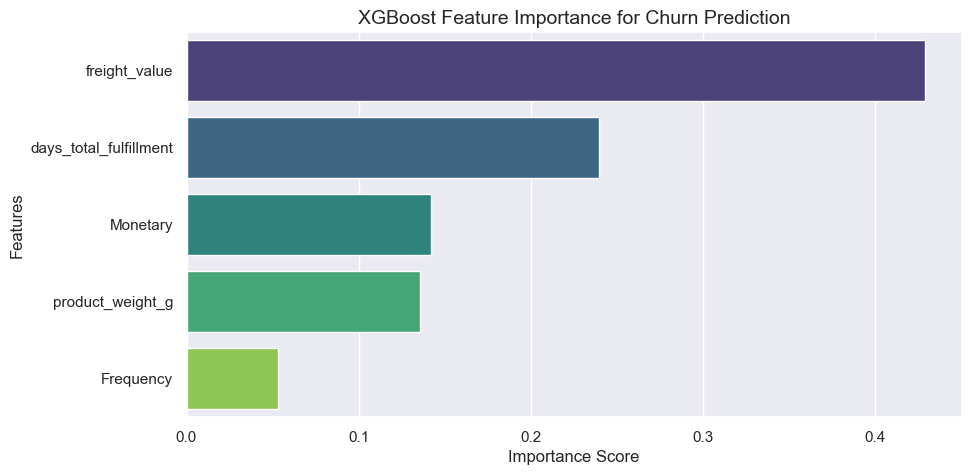

In [4]:
# 7. 训练模型并获取重要性指标
xgb_model, auc_score, feature_importance = rfm_model.train_churn_model(df_rfm)

print(f"🚀 XGBoost Model Trained Successfully! \nROC-AUC Score: {auc_score:.4f}")
print("(AUC 分数说明模型具备良好的区分流失与非流失用户的能力)")

# 8. 可视化特征重要性
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')
plt.title("XGBoost Feature Importance for Churn Prediction", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [5]:
# 9. 保存带标签的 RFM 数据，供给模块四的终极 Dashboard 渲染
df_rfm.to_parquet("../data/processed/olist_rfm_segments.parquet", index=False)
print("Data saved successfully for final Dashboard generation.")

Data saved successfully for final Dashboard generation.
